> **Note:** If you're running in Google Colab, make sure to enable GPU usage by going to Runtime -> Change runtime type -> select GPU.

[Source Code](https://github.com/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_llm_full_fine_tune_tutorial.ipynb)


## Overview

Let's fine-tune a Small Vision Language Model (VLM) for a structured data extraction task.

More specifically, we'll fine-tune a VLM for extracting food and drink items from images to JSON.

Goal: 

* Input: Food or not food image
* Output: Structured data for whether or not the image is food or not + food/drink tags

For example:

* Input (image): A photo of a pork ribs, tomato, grilled onions, carrots and cilantro.
* Output:

```
{
    "is_food": 1,
    "image_title": "grilled ribs roasted carrots grilled onions tomato salsa",
    "food_items": [
        "rib meat",
        "onion",
        "grilled onion slice",
        "garlic",
        "rib bone",
        "cilantro",
        "cherry tomato",
        "carrot"
    ],
    "drink_items": []
}
```

TK image - of input + output

## What is a Vision Language Model?

A Vision Language Model combines vision with language in a single model.

Sometimes this is called a "Multi-Modal Language Model" or MLLM (you can also see these models on Hugging Face as `Image-Text-to-Text`) .

A VLM allows LLMs to interact with images (and sometimes videos), essentially allowing them to see.

A VLM brings the generality of LLMs to the visual world for use cases such as:

* Extracting information from documents.
* Inferring what foods/drinks are in an image for a nutrition tracking task.
* Picking up on potential visual issues in a manufacturing plant.
* Monitoring an area for security purposes.

## Why fine-tune a Small Vision Language Model?

1. Ownership - Own the model, can run on own hardware (data stays local + private)

2. Simple - Our task is simple enough to just use a small language model (save $$)

3. Infinite inference - No API calls needed (can be run offline if needed, save $$)

4. Batch mode for scale - Can run in batch mode to get much faster inference than single API calls (can do this with APIs, however, still requires an API usage) 

5. Make base models *much* better - Model by default wasn't very good at our task but now since fine-tuning, can be *very good*

> **Note:** You can often use traditional computer vision models such as ViT (Vision Transformer) for many tasks. However, the benefit of a VLM is the introduction of it being able to generalize to *many* different tasks as long as you specify the inputs and outputs.

## VLM/LLM Fine-tuning Mindset

In LLM/VLMworld, data inputs are tokens and data outputs are tokens.

A token is a numerical representation of some kind of data.

Computers like numbers (not images, text, videos, etc).

Everything must be turned into numbers.

And data = a very broad term.

It could be text, images, video (series of images), audio, DNA sequences, Excel spreadsheets, you name it.

The goal of the VLM/LLM is to be given an input sequence of tokens and then predict the following tokens.

So with this mindset, you can think of any problem as **tokens in, tokens out**.

Ask yourself: *What tokens do I want to put in and what tokens do I want my model to return?*

In our case, we want to put in almost any image + string input. 

And we want to get back structured information specifically related to food and drinks.

This a very specific use case, however, the beauty of LLMs being so general is that you can apply this **tokens in, tokens out** mindset to almost anything.

If you've got an existing dataset (no problem if you don't, you can create one, let me know if you'd like a guide on this), chances are, you can fine-tune an VLM/LLM to do pretty well on it.

## Resources

### Hardware

I'm running this notebook/tutorial locally on a [NVIDIA DGX Spark](https://nvda.ws/4iQXZU4).

However, you can also run it in Google Colab.

It is recommended you use a NVIDIA GPU.

### Models, data and demos

* Dataset we'll be using - https://huggingface.co/datasets/mrdbourke/FoodExtract-1k-Vision 
* Base model we'll be fine-tuning - https://huggingface.co/HuggingFaceTB/SmolVLM2-500M-Video-Instruct
* Example demo we'll be creating - https://huggingface.co/spaces/mrdbourke/FoodExtract-Vision-v1
* Fine-tuned model we'll be creating - https://huggingface.co/mrdbourke/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1

### Documentation and extras

* Dataset format for VLM fine-tuning: https://huggingface.co/docs/trl/en/dataset_formats#vision-datasets 
* Hugging Face blog post of what is a VLM: https://huggingface.co/blog/vlms-2025
* Hugging Face docs of fine-tuning SmolVLM: https://github.com/huggingface/smollm/blob/main/vision/finetuning/Smol_VLM_FT.ipynb 
* Google Docs example of fine-tuning a VLM: https://ai.google.dev/gemma/docs/core/huggingface_vision_finetune_qlora 
* Another doc example of inference with a VLM: https://github.com/google-gemini/gemma-cookbook/blob/main/Gemma/%5BGemma_3n%5DMultimodal_understanding_with_HF.ipynb 
* LoRA without regret blog post: https://huggingface.co/docs/trl/main/en/lora_without_regret 
    * Thinking Machines blog: https://thinkingmachines.ai/blog/lora/ 
* Example of LoRA in the wild: https://developer.apple.com/apple-intelligence/foundation-models-adapter/ 
* PEFT (Parameter Efficient Fine-tuning) GitHub - https://github.com/huggingface/peft 
* SmolVLM Docling paper - https://arxiv.org/pdf/2503.11576 
    * Notes:
        * LLM alignment: To align the LLM part we freeze the vision encoder and train only the remaining network to adapt it to the new output format which it hasn't seen before.
        * Unfreeze vision encoder: After LLM alignment, unfreeze vision encoder and train the model on pretraining datasets (section 4.1) along with all task-specific conversion datasets including tables, code, equations and charts. 
        * Workflow:
            * Stage 1 (frozen vision encoder): Freeze the vision encoder and teach the LLM part to output our desired structure (e.g. JSON for food/drink)
                * Note: Create a Trainer instance (SFTTrainer) with one optimizer to get the state of the model and optimize it with a frozen vision backbone.
            * Stage 2 (unfrozen whole model): Unfreeze the vision encoder and teach the whole model to converge to your desired structure.
                * Note: Create a 2nd Trainer instance (e.g. `Trainer_2`) with a *new* optimizer to get the state of the whole model (with unfrozen backbone) and optimize it with the whole model as trainable.

## Definitions

* Base Model = A model which has been trained by someone else (e.g. a company, group of researchers or individual) we can download from a location such as Hugging Face and fine-tune/customize to our own liking.
* Small Vision Language Model = A Vision Language Model (VLM) with a number of parameters under 1B (1 billion), this kind of Vision Language Model is small enough to be deployed to mobile/edge devices.
    * **Note:** Models larger than 1B can be deployed to edge devices, however, I specifically reserve the *small* title for models under 1B parameters.
* PEFT = Parameter Efficient Fine-Tuning (only train a subset of the model parameters + hopefully still get good results)
* LoRA = Low Rank Adaptation (LoRA = a form of PEFT) - https://arxiv.org/abs/2106.09685
    * You basically fine-tune an adapter model for your original model and optionally apply the adatper to the original model
    * Benefits of LoRA = you can train multiple adapters only and run those at different times depending on the required use case of your model 
* QLoRA = Quantized LoRA (fine-tune an adapter)
    * Train with quantized weights (even smaller than LoRA) for even more parameter efficient fine-tuning
 
> **Note:** We're not using PEFT in this notebook as our model is small enough to fine-tune a significant portion of it. In my experience, PEFT is better suited to larger models which are harder to fully fine-tune without significant hardware.
>
> We'll use PEFT in a future tutorial where we customize a larger model (with more than 1B parameters) for a specific task.

## Import Dependencies

If you are running this notebook in Google Colab, you may need to install the following.

In [2]:
import transformers
import trl

import torch

from transformers import BitsAndBytesConfig

from peft import LoraConfig

# Note: I'm running this locally on a NVIDIA DGX Spark, if you are running on Google Colab, make sure you've activate a GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")


[INFO] Using device: cuda


## Load dataset

VLM datasets follow the main structure of "image + text pairs".

For example, you in put an image, what text do you want out?

I created this dataset to be:

* 1000 food images (from Food101)
* 500 not food images (randomly sampled from the internet)

The images were labelled to extract food/drink items with [`Qwen3-VL-8B-Instruct`](https://huggingface.co/Qwen/Qwen3-VL-8B-Instruct) (a larger VLM) and then turned into a [Hugging Face Image Dataset](https://huggingface.co/docs/datasets/en/image_dataset#imagefolder). 

> **Resource:** If you'd like to see how I created this dataset, refer to the [livestream I did on YouTube](https://www.youtube.com/live/X-nYCCviCyI?si=kPKhTxXbc7pUztAC) where I build the dataset and uploaded it to Hugging Face.

In [3]:
from datasets import load_dataset
from PIL import Image

dataset = load_dataset("mrdbourke/FoodExtract-1k-Vision")
dataset

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image'],
        num_rows: 1510
    })
})

In [4]:
example_sample = dataset["train"][0]

example_sample

{'image_id': '3233632',
 'image_name': '3233632.jpg',
 'food101_class_name': 'cheese_plate',
 'food101_split': 'train',
 'image_source': 'food101',
 'qwen3_vl_8b_yaml_out': 'point_of_view: 45-degree\ndishes:\n  - cheese plate\nfood_items:\n  - cheese wedge\n  - toast\n  - herb garnish\n  - dipping sauce\ndrink_items: []\ncontainers_and_utensils:\n  - white plate\n  - small white bowl\nattributes:\n  - sliced\n  - garnished\n  - served with accompaniments',
 'qwen3_vl_inference_time': 1.6110260486602783,
 'output_label_json': {'is_food': 1,
  'image_title': 'cheese plate',
  'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'],
  'drink_items': []},
 'is_food': 1,
 'image': <PIL.Image.Image image mode=RGB size=512x512>}

We get some details back from our dataset, the main two fields we're going to focus on are:

* `image` - This is an image we'd like to input into our model and get back structured data from.
* `output_label_json` - This is the structured data we'd like our fine-tuned model to return. This is JSON but our model will return strings (text). We can train our model to return valid JSON so we can easily extract detials from the string output and put them into a database.

[INFO] Example desired output:
{'is_food': 1, 'image_title': 'cheese plate', 'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'], 'drink_items': []}
[INFO] Example image input:


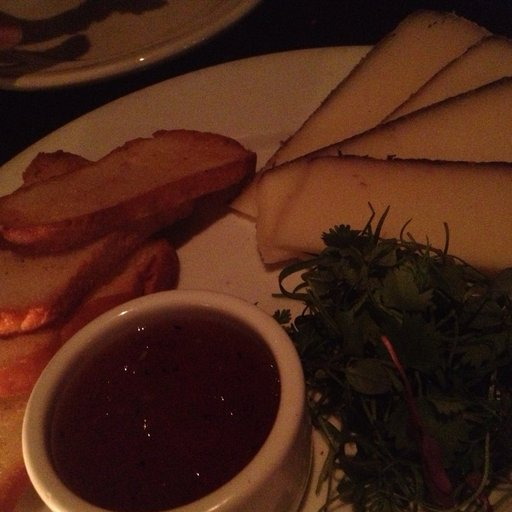

In [5]:
example_input = example_sample["image"]
example_output = example_sample["output_label_json"]

print(f"[INFO] Example desired output:\n{example_output}")

print(f"[INFO] Example image input:")
example_input

## Format data for use with a VLM

Our VLM input requires our data to be formatted in a conversational style.

We'll use two prompts to try and help the model: 

```
SYSYTEM_MESSAGE = """You are an expert food and drink image extractor.
You provide structured data to visual inputs classifying them as edible food/drink or not.
As well as titling the image with a simple food/drink related caption.
Finally you extract any and all visible food/drink items to lists.
"""
```

And

````
USER_PROMPT = """Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.

Only return valid JSON in the following form:

```json
{
  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)
  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present
  'food_items': [], # list[str] - list of visible edible food item nouns
  'drink_items': [] # list[str] - list of visible edible drink item nouns
}
```
"""
````

To begin, we'll see how the base model performs using just these prompts.

In [6]:
# System message
SYSYTEM_MESSAGE = """You are an expert food and drink image extractor.
You provide structured data to visual inputs classifying them as edible food/drink or not.
As well as titling the image with a simple food/drink related caption.
Finally you extract any and all visible food/drink items to lists.
"""

# User prompt with image input as well as desired output
USER_PROMPT = """Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.

Only return valid JSON in the following form:

```json
{
  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)
  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present
  'food_items': [], # list[str] - list of visible edible food item nouns
  'drink_items': [] # list[str] - list of visible edible drink item nouns
}
```
"""

# Create helper function to map our input/output samples to conversational format
def format_data(sample):
    return {
        "messages": [

            # Message 0 - [SYSTEM] System Prompt (setting the scene)
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSYTEM_MESSAGE}]
            },

            # Message 1 - [USER] User input (image + prompt pair)
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": sample["image"],
                    },
                    {
                        "type": "text",
                        "text": USER_PROMPT # Note: In a future extension, you might train the model to not require any text input and just go straight from image -> text output
                    }
                ],
            },

            # Message 2 - [MODEL] Ideal model output (e.g. our structured data format)
            {
                "role": "assistant",
                "content": [{"type": "text", "text": sample["output_label_json"]}]
            }
        ]
    }

formatted_sample = format_data(sample=example_sample)
formatted_sample

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=512x512>},
    {'type': 'text',
     'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods pr

In [9]:
# Format each item in the original dataset keeping the PIL image type
# Note: We're using a for loop here instead of dataset.map() as seen below because map() seems to get jammed.
dataset_processed = [format_data(sample) for sample in dataset["train"]]
dataset_processed[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=512x512>},
    {'type': 'text',
     'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods pr

In [8]:
# Note: Tried .map() but it seems to get stuck and took too long. We can investigate this in the future... skipping for now

# dataset = dataset.map(format_data)
# dataset["train"][0]

Wonderful! Our data is now in chat message format, let's see what happens when we run a sample through a base model (this model hasn't been fine-tuned our data yet).

### Create a training and validation split

Let's split our data into training/validation.

We will fine-tune on the training data and then evaluate our model on the validation data.

In [37]:
import random
from pprint import pprint

random.seed(42)
dataset_shuffled = random.sample(dataset_processed, k=len(dataset_processed))

# Use 80% split for training, 20% for validation
train_split = round(0.8 * len(dataset_shuffled))

train_dataset = dataset_shuffled[:train_split]
val_dataset = dataset_shuffled[train_split:]
print(f"[INFO] Number of total samples: {len(dataset_processed)}")
print(f"[INFO] Number of train samples: {len(train_dataset)}")
print(f"[INFO] Number of eval samples: {len(val_dataset)}")

print(f"\n[INFO] Example training sample:\n")
pprint(train_dataset[0])
print(f"\n[INFO] Example validation sample:\n")
pprint(val_dataset[0])

[INFO] Number of total samples: 1510
[INFO] Number of train samples: 1208
[INFO] Number of eval samples: 302

[INFO] Example training sample:

{'messages': [{'content': [{'text': 'You are an expert food and drink image '
                                    'extractor.\n'
                                    'You provide structured data to visual '
                                    'inputs classifying them as edible '
                                    'food/drink or not.\n'
                                    'As well as titling the image with a '
                                    'simple food/drink related caption.\n'
                                    'Finally you extract any and all visible '
                                    'food/drink items to lists.\n',
                            'type': 'text'}],
               'role': 'system'},
              {'content': [{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x678 at 0xE011B5F5E450>,
                     

## Running a sample through a base model

Let's see how a non-fine-tuned model performs on our task.

* Let's fine-tune SmolVLM2-256M or SmolVLM2-500M
    * See collection: https://huggingface.co/collections/HuggingFaceTB/smolvlm2-smallest-video-lm-ever 
* Previous efforts we tried gemma-3n-E3B-it but it was already too good:
    * ~To begin with we'll try out Gemma-3n-E2B-it - https://huggingface.co/google/gemma-3n-E2B-it~

In [11]:
# Get a base model input example
# We only want our model to see the user system/user inputs (not the desired response) so we index on the correct amount of messages
example_base_model_input = dataset_processed[0]["messages"][:2]
example_base_model_input

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.Image.Image image mode=RGB size=512x512>},
   {'type': 'text',
    'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present\n  'food_items

### Loading a base model

There are many different VLMs we could try.

But for this project, we're going to focus on small (under 1B parameters).

In previous experiments I tried `google/gemma-3n-e2b-it` (5B parameters) and it performed quite well on our task.

For now we'll stick with [`HuggingFaceTB/SmolVLM2-500M-Video-Instruct`](https://huggingface.co/HuggingFaceTB/SmolVLM2-500M-Video-Instruct), a model 10x smaller than `google/gemma-3n-e2b-it`.

So it's a good place to start to try and make it perform on par with a larger model.

> **Resource:** You can find many base models the Hugging Face Models page under the `Image-Text-to-Text` filter: https://huggingface.co/models?pipeline_tag=image-text-to-text

In [13]:
from transformers import pipeline

# MODEL_ID = "google/gemma-3n-e2b-it"
# MODEL_ID = "HuggingFaceTB/SmolVLM2-256M-Video-Instruct"

MODEL_ID = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"

pipe = pipeline(
    "image-text-to-text",
    model=MODEL_ID,
    device="cuda",
    dtype=torch.bfloat16
)

Device set to use cuda
/home/mrdbourke/miniforge3/envs/ai/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


In [17]:
# Test the base model on an example input image
base_model_output = pipe(text=example_base_model_input,
                         max_new_tokens=256)

print(f'[INFO] Base model input (text only):\n{example_base_model_input}\n')
print(f'[INFO] Base model output:\n{base_model_output[0]["generated_text"][-1]["content"]}\n')
print(f'[INFO] Desired output:\n{dataset_processed[0]["messages"][-1]["content"][0]["text"]}')

[INFO] Base model input (text only):
[{'role': 'system', 'content': [{'type': 'text', 'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]}, {'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=512x512 at 0xE011B68CCC50>}, {'type': 'text', 'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank

Hmmm... doesn't look like our base model outputs what we'd like.

It seems as though it's outputing an empty list.

But I'm pretty sure our image has food items in it...

Let's check it.

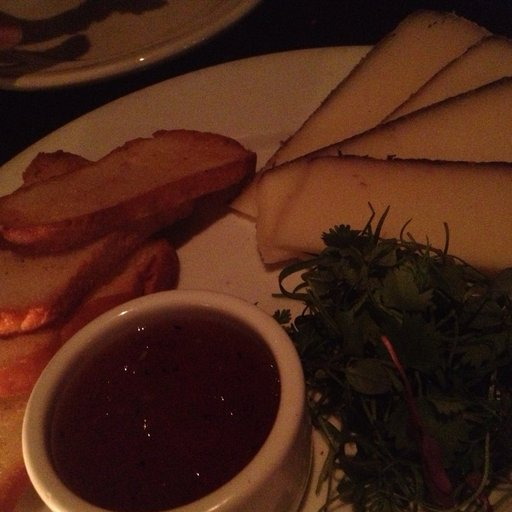

In [15]:
# Check example input image
example_base_model_input[1]["content"][0]["image"]

It definitely does have food in it!

Ideally our model would output something like: 

```
{'is_food': 1, 
 'image_title': 
 'cheese plate', 
 'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'], 
 'drink_items': []}
```

But alas... it did not.

Let's see if fine-tuning helps!

## Load the model without using pipeline

`transformers.pipeline` allows simple loading and inference of the model.

But for more customization we'll want to load the model directly. 

In [45]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

print(f"[INFO] Using model: {MODEL_ID}")

# Define model init args 
model_kwargs = dict(
    attn_implementation="eager", # Note: could also use flash_attention_2 here for faster models, requires `pip install flash-attn` (see: https://github.com/Dao-AILab/flash-attention)
    dtype=torch.bfloat16,
    device_map="auto"
)

# Load the model and tokenizer/processor
model = AutoModelForImageTextToText.from_pretrained(MODEL_ID,
                                                    **model_kwargs)
processor = AutoProcessor.from_pretrained(MODEL_ID)

[INFO] Using model: HuggingFaceTB/SmolVLM2-500M-Video-Instruct


We can inspect our model's architecture for modification later on. 

In [47]:
# Inspect our model's architecture
model

SmolVLMForConditionalGeneration(
  (model): SmolVLMModel(
    (vision_model): SmolVLMVisionTransformer(
      (embeddings): SmolVLMVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): SmolVLMEncoder(
        (layers): ModuleList(
          (0-11): 12 x SmolVLMEncoderLayer(
            (self_attn): SmolVLMVisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): SmolVLMVisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out_feature

Take note of the major components:

* `vision_model` - This will encode our image, in the case of SmolVLM2, it uses the [SigLIP](https://huggingface.co/google/siglip-base-patch16-512) vision language model as an encoder.
* `text_model` - This will encode our text into a numerical representation. Under the hood SmolVLM2 uses [SmolLM2-360M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-360M-Instruct).
* `connector` - This module will connect the individual `vision_model` and `text_model` and combine them into the same feature space.
* `lm_head` - This module will output tokens that have been conditioned on both vision and language data.

To begin, we will fine-tune all components *except* the `vision_model` as this is what is reflected in the [literature](https://arxiv.org/abs/2503.11576) as well as what I've found to work in practice.

Let's run a single sample through our `model`.

In [48]:
# Apply the chat template 
example_chat_template_input = processor.apply_chat_template(
    [example_base_model_input[1]], # Note: if we are running this way, format the system_prompt to either be removed or folded into the user_prompt
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(device)

# Measure how long our input prompt is (our model will generate tokens *after* the input prompt)
input_len = example_chat_template_input["input_ids"].shape[-1]
print(f"[INFO] Input length: {input_len}")

# Perform inference with the base model
with torch.no_grad():
    generation_output_full = model.generate(**example_chat_template_input,
                                            max_new_tokens=256,
                                            do_sample=False)
    generation_output_short = generation_output_full[0][input_len:]

# Decode the outputs from tokens -> readable text
decoded_outputs = processor.decode(generation_output_short,
                                   skip_special_tokens=True)

# Print inputs and outputs
print("\n"+"-"*50+"\n")
print(f"[INFO] This is the raw token (numerical) intput to our model:\n")
print(example_chat_template_input["input_ids"][0])
print("\n"+"-"*50+"\n")
print(f"[INFO] This is the raw pixel values (numerical) intput to our model:\n")
print(example_chat_template_input["pixel_values"][0])
print("\n"+"-"*50+"\n")
print(f"[INFO] This is the input to our model in human-readable form (note: our model will not see in the input like this):\n")
print(processor.decode(example_chat_template_input["input_ids"][0]))
print("\n"+"-"*50+"\n")
print(f"[INFO] Outputs from the model:\n")
print(decoded_outputs)

[INFO] Input length: 1310

--------------------------------------------------

[INFO] This is the raw token (numerical) intput to our model:

tensor([    1, 11126,    42,  ...,  9519,  9531,    42], device='cuda:0')

--------------------------------------------------

[INFO] This is the raw pixel values (numerical) intput to our model:

tensor([[[[-0.3804, -0.3804, -0.3804,  ..., -0.8431, -0.8431, -0.8353],
          [-0.3804, -0.3804, -0.3804,  ..., -0.8353, -0.8353, -0.8275],
          [-0.3804, -0.3804, -0.3804,  ..., -0.8353, -0.8353, -0.8275],
          ...,
          [-0.9216, -0.9216, -0.9216,  ..., -0.0667, -0.0667, -0.0745],
          [-0.9216, -0.9216, -0.9216,  ..., -0.0667, -0.0667, -0.0745],
          [-0.9137, -0.9137, -0.9137,  ..., -0.0745, -0.0745, -0.0745]],

         [[-0.6549, -0.6549, -0.6549,  ..., -0.9216, -0.9216, -0.9059],
          [-0.6549, -0.6549, -0.6549,  ..., -0.9137, -0.9137, -0.8980],
          [-0.6549, -0.6549, -0.6549,  ..., -0.9137, -0.9137, -0.898

Okay... so it looks like our base `model` is outputting an empty list just like our `pipe` from before.

We'll try to improve this via fine-tuning.

> **Note:** Notice the `<image>` special tokens which represent our image in text format which will go into the model. In this form, the token here is just a placeholder token. The actual feature values of the `<image>` token will come from the `vision_model` in the `example_chat_template_input["pixel_values"]` key.

## Prepare model for training

As per the [SmolDocling paper (section 5.1)](https://arxiv.org/pdf/2503.11576), we're going to freeze the `vision_model` and train the rest of the model (the LLM parts).

If we had a larger dataset (our dataset is quite small at ~1000 training samples), we could potentially perform two stage training by:

1. Training with a frozen vision encoder to align the LLM portions of the model to output our desired format.
2. Training the whole model to align all features to our target dataset.

For now, we are going to focus on stage one.

Let's count the overall parameters and trainable parameters in our model before and after freezing the vision encoder.

In [49]:
# Freeze the vision backbone and only train the LLM parts
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen 

# Before freezing parameters
total_params, trainable_params, frozen_params = count_parameters(model)
print(f"[INFO] Params Total (before freezing the vision model): {total_params:,} | Params Trainable: {trainable_params:,} | Params Frozen: {frozen_params:,}")

# Freeze the vision encoder
for param in model.model.vision_model.parameters():
    # Turn off graidents in the vision model
    param.requires_grad = False

# After freezing parameters
total_params, trainable_params, frozen_params = count_parameters(model)
print(f"[INFO] Params Total (after freezing the vision model): {total_params:,} | Params Trainable: {trainable_params:,} | Params Frozen: {frozen_params:,}")

[INFO] Params Total (before freezing the vision model): 507,482,304 | Params Trainable: 507,482,304 | Params Frozen: 0
[INFO] Params Total (after freezing the vision model): 507,482,304 | Params Trainable: 421,049,280 | Params Frozen: 86,433,024


## Creating a data collator

A data collator helps stack our image + text samples into batches. 

This tells the `transformer.Trainer` how to put multiple samples into a batch for more efficient training.

To do this we'll create two functions:

1. `convert_message_to_list_of_images` - Extracts the images from an input list of messages (our image + text pairs) to a list.
2. `collate_fn` - Preprocesses groups of image and text pairs into batches for our model to train on.

In [51]:
def convert_message_to_list_of_images(messages: list[dict]) -> list[Image.Image]:
    """Helper function to turn our message samples into lists of images.
    
    Note: this comes from here: https://ai.google.dev/gemma/docs/core/huggingface_vision_finetune_qlora"""
    image_inputs = []
    
    # Iterate through each conversation
    for msg in messages:
        # Get content (ensure it's a list)
        content = msg.get("content", [])
        if not isinstance(content, list):
            content = [content]

        # Check each content element for images
        for element in content:
            if isinstance(element, dict) and (
                "image" in element or element.get("type") == "image"
            ):
                # Get the image and convert to RGB
                if "image" in element:
                    image = element["image"]
                else:
                    image = element
                image_inputs.append(image.convert("RGB"))
                
    return image_inputs

def collate_fn(examples):
    """Helper function to stack together image + text pairs into batches."""
    
    # Create empty lists for batches of text and images
    texts = []
    images = []

    # Loop through examples and preprocess them
    for example in examples:
        image_inputs = convert_message_to_list_of_images(example["messages"])
        text = processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        )
        texts.append(text.strip())
        images.append(image_inputs)
    
    # Tokenize the texts and process the images
    batch_input = processor(text=texts, 
                            images=images, 
                            return_tensors="pt",
                            padding=True) 
    
    # The labels are the input_ids and we mask the padding tokens and image tokens in the loss computation
    labels = batch_input["input_ids"].clone()

    # Get the image token
    image_token_id = processor.tokenizer.additional_special_tokens_ids[
            processor.tokenizer.additional_special_tokens.index("<image>")]

    # Mask tokens for not being used in the loss computation
    labels[labels == processor.tokenizer.pad_token_id] = -100 # pad_token_id = 2
    labels[labels == image_token_id] = -100 # image_token_id = 49190, this is the `<image>` token which is a placeholder, we don't need our model to learn to predict those

    batch_input["labels"] = labels
    
    return batch_input

# For SmolVLM2, check the image token
image_token_id = processor.tokenizer.additional_special_tokens_ids[
            processor.tokenizer.additional_special_tokens.index("<image>")]
print(f"[INFO] SmolVLM2 uses the following for the image_token_id: {image_token_id}, we mask this token as it is only a placeholder in our sequence of tokens (we don't need the model to learn to predict it).")

[INFO] SmolVLM2 uses the following for the image_token_id: 49190, we mask this token as it is only a placeholder in our sequence of tokens (we don't need the model to learn to predict it).


> **Note:** When fine-tuning a model be sure to take note of what tokens a different tokenizer uses for different items.
>
> If you use the wrong tokenizer/wrong tokens for a certain model

## Setup SFTConfig

We're going to use SFT (Supervised Fine-Tuning) which is a method of training where we provide input + output pairs for our model. 

Given an input and output pair, our model will be directly trained to predict the output based on the input.

TK - UPTOHERE config + trainer 


In [52]:
from trl import SFTConfig

# Note: Many of these hyperparameters have been taken from the SmolDocling paper: 
training_args = SFTConfig(
    output_dir="smolvlm2-500m-FoodExtract-Vision-v1-VIDEO",
    num_train_epochs=4,
    per_device_train_batch_size=4, # adjust based on the size of your GPU
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    bf16=True,
    save_total_limit=1,
    max_grad_norm=1.0, 
    warmup_ratio=0.03, 
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to="none",
    gradient_checkpointing_kwargs={
        "use_reentrant": False
    },
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    load_best_model_at_end=True,
    remove_unused_columns = False 
)

## Train the model with SFTTrainer

In [46]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    # train_dataset=train_dataset[:1000],
    # eval_dataset=val_dataset[:50], 
    train_dataset=train_dataset[:100] # Lowered for the video (faster)
    eval_dataset=val_dataset[:50], # Lowered for the video (faster)
    # peft_config=peft_config, # Note: We are not using PEFT but if we did, we could pass it in here
    processing_class=processor,
    data_collator=collate_fn
)

trainer.train()

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.085500,0.078648,0.761998,1279540.000000,0.981073
2,0.061000,0.076550,0.863953,2559080.000000,0.982080
3,0.039000,0.079153,1.057484,3838620.000000,0.982037
4,0.027800,0.083432,1.019404,5118160.000000,0.981700


TrainOutput(global_step=252, training_loss=0.08351177994220976, metrics={'train_runtime': 5522.2035, 'train_samples_per_second': 0.724, 'train_steps_per_second': 0.046, 'total_flos': 1.5640630362196992e+16, 'train_loss': 0.08351177994220976, 'epoch': 4.0})

You should see an output similar to this:

```
[252/252 1:31:40, Epoch 4/4]
Epoch	Training Loss	Validation Loss	Entropy	Num Tokens	Mean Token Accuracy
1	0.085500	0.078648	0.761998	1279540.000000	0.981073
2	0.061000	0.076550	0.863953	2559080.000000	0.982080
3	0.039000	0.079153	1.057484	3838620.000000	0.982037
4	0.027800	0.083432	1.019404	5118160.000000	0.981700
```

 This model is available here: https://huggingface.co/mrdbourke/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1 (in the video demo, I dramatically lowered the number of samples used to speed up training time)

In [47]:
# Save the model to file 
trainer.save_model()

### Plot the training/validation loss curves

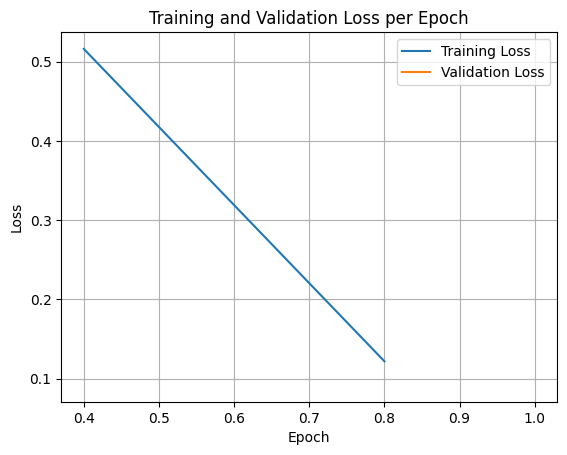

In [51]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## Upload the fine-tuned model to the Hugging Face Hub

> **Note:** Make sure you are authenticated to the Hugging Face Hub via the [`huggingface_hub` package](https://huggingface.co/docs/huggingface_hub/en/guides/cli) to enable smooth uploads.
>
> See the [`hf auth login` command](https://huggingface.co/docs/huggingface_hub/en/guides/cli#hf-auth-login) for details on how to obtain an authorization token to link your computer to your Hugging Face profile via a [User Access Token](https://huggingface.co/docs/hub/security-tokens).

In [ ]:
# Optional: Remove the checkpoints from the saved directory 


In [ ]:
# Upload to Hugging Face
from huggingface_hub import HfApi, create_repo 

api = HfApi()

# Give our model a name (this is in the format [Hugging Face Username]/[Target Model Name]
repo_id = "mrdbourke/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1-VIDEO"

# Create the repo
create_repo(repo_id, 
            repo_type="model", 
            exist_ok=True)

# Upload the entire model folder containing our model files
api.upload_folder(
    folder_path="./smolvlm2-500m-FoodExtract-Vision-v1-VIDEO/",
    repo_id=repo_id,
    repo_type="model"
)

## Test the fine-tuned model against the base model

In [53]:
del model
del trainer
torch.cuda.empty_cache()

In [55]:
CHECKPOINT_DIR_NAME = training_args.output_dir
print(f"[INFO] Using fine-tuned checkpoint: {CHECKPOINT_DIR_NAME}")
print(f"[INFO] Using base model checkpoint: {OUTPUT_DIR}")

In [56]:
from transformers import pipeline

# Load the base model (pt_pipe stands for "pretrained pipeline", 'pretrained model' is another word for 'base model'
pt_pipe = pipeline(
    "image-text-to-text",
    model=MODEL_ID,
    dtype=torch.bfloat16
)

# `do_sample = False` for deterministic responses
pt_pipe.model.generation_config.do_sample = False
pt_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

# Load the fine-tuned model
ft_pipe = pipeline(
    "image-text-to-text",
    model=CHECKPOINT_DIR_NAME,
    dtype=torch.bfloat16
)

# `do_sample = False` for deterministic responses
ft_pipe.model.generation_config.do_sample = True
ft_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

Device set to use cuda:0


In [63]:
pt_pipe.device, ft_pipe.device

(device(type='cuda', index=0), device(type='cuda', index=0))

[INFO] Example model input:
{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=512x512 at 0xEBE84E577530>}, {'type': 'text', 'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present\n  'food_items': [], # list[str] - list of visible edible food item nouns\n  'drink_items': [] # list[str] - list of visible edible drink item nouns\n}\n```\n"}]}

[INFO] Example model output:
{'role': 'assistant', 'content': [{'type': 'text', 'text': {'is_food': 1, 'image_title': 'ramen', 'food_items': ['wheat noodles', 'broth', 'gr

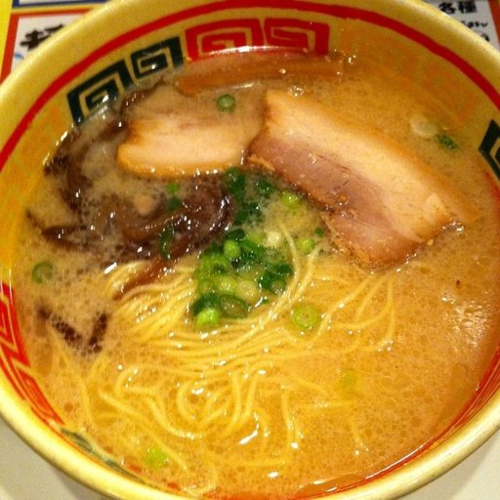

In [72]:
import random

# Pick a random sample from the validation dataset
random_val_sample = random.choice(val_dataset)
random_val_sample_model_input = random_val_sample["messages"][1]
random_val_sample_image = random_val_sample_model_input["content"][0]["image"]
random_val_sample_model_output = random_val_sample["messages"][-1]

# Print out the ideal input and outputs
print(f"[INFO] Example model input:\n{random_val_sample_model_input}")
print()
print(f"[INFO] Example model ideal output:\n{random_val_sample_model_output["content"][0]["text"]}")

# Perform a forward pass with the base model
pt_pipe_output = pt_pipe(text=[random_val_sample_model_input],
                         max_new_tokens=256)
pt_pipe_output_text = pt_pipe_output[0]["generated_text"][-1]["content"]
print(f"\n[INFO] Generated output text from pre-trained model:\n{pt_pipe_output_text}\n")

# Perform a forward pass with the fine-tuned model
ft_pipe_output = ft_pipe(text=[random_val_sample_model_input],
                         max_new_tokens=256)
ft_pipe_output_text = ft_pipe_output[0]["generated_text"][-1]["content"]
print(f"\n[INFO] Generated output text from fine-tuned model:\n{ft_pipe_output_text}\n")

print(f"[INFO] Intput image:")
random_val_sample_image.resize(size=(500, 500))

## Optional: Training Stage 2: Unfreezing the vision encoder 

Let's unfreeze the vision encoder and see if it provides any improvements to our model.

To do so, we'll have to create another instance of `transformers.Trainer` to exstablish a new optimizer.

In [58]:
# model_stage_1 = ft_pipe.model

# # Unfreeze vision encoder
# total_params, trainable_params, frozen_params = count_parameters(model_stage_1)
# print(f"[INFO] Params Total: {total_params:,} | Params Trainable: {trainable_params:,} | Params Frozen: {frozen_params:,}")

# # Unfreeze the vision encoder
# for param in model_stage_1.model.vision_model.parameters():
#     # Turn off graidents in the vision model
#     param.requires_grad = True

# # After freezing parameters
# total_params, trainable_params, frozen_params = count_parameters(model_stage_1)
# print(f"[INFO] Params Total: {total_params:,} | Params Trainable: {trainable_params:,} | Params Frozen: {frozen_params:,}")

In [59]:
# from trl import SFTConfig

# training_args_stage_2 = SFTConfig(
#     output_dir="smolvlm2-256m-FoodExtract-Vision-stage-2-v1",
#     num_train_epochs=1,
#     per_device_train_batch_size=4,
#     per_device_eval_batch_size=4,
#     gradient_accumulation_steps=4,
#     gradient_checkpointing=True,
#     optim="adamw_torch_fused",
#     logging_steps=1,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-6,
#     bf16=True,
#     save_total_limit=1,
#     max_grad_norm=1.0, 
#     warmup_ratio=0.03, 
#     lr_scheduler_type="constant",
#     push_to_hub=False,
#     report_to="none",
#     gradient_checkpointing_kwargs={
#         "use_reentrant": False
#     },
#     dataset_text_field="",
#     dataset_kwargs={"skip_prepare_dataset": True},
#     load_best_model_at_end=True
# )
# training_args_stage_2.remove_unused_columns = False # important for collator

# from trl import SFTTrainer

# trainer_stage_2 = SFTTrainer(
#     model=model_stage_1,
#     args=training_args_stage_2,
#     train_dataset=train_dataset[:1000],
#     eval_dataset=val_dataset[:100],
#     # peft_config=peft_config, # Note: if the model is already PEFT-ified, don't need to re-pass the PEFT config 
#     processing_class=processor,
#     data_collator=collate_fn
# )

# trainer_stage_2.train()

In [56]:
# ft_pipe_stage_2 = pipeline(
#     "image-text-to-text",
#     model=CHECKPOINT_DIR_NAME_STAGE_2,
#     dtype=torch.bfloat16
# )

# processor = AutoProcessor.from_pretrained(CHECKPOINT_DIR_NAME_STAGE_2)

# # `do_sample = False` for deterministic responses
# ft_pipe_stage_2.model.generation_config.do_sample = True
# ft_pipe_stage_2.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

In [57]:
# TODO: test the stage 2 model on a test image

## Create a demo with Gradio

In [18]:
%%writefile demos/FoodExtract-Vision-v1/app.py
import torch
import gradio as gr

import spaces
from transformers import pipeline

BASE_MODEL_ID = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"
FINE_TUNED_MODEL_ID = "mrdbourke/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1"
OUTPUT_TOKENS = 256

# Load original base model (no fine-tuning)
print(f"[INFO] Loading Original Model")
original_pipeline = pipeline(
    "image-text-to-text",
    model=BASE_MODEL_ID,
    
    dtype=torch.bfloat16,
    device_map="auto"
)

# Load fine-tuned model
print(f"[INFO] Loading Fine-tuned Model")
ft_pipe = pipeline(
    "image-text-to-text",
    model=FINE_TUNED_MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto"
)
    
def create_message(input_image):
    return [{'role': 'user',
 'content': [{'type': 'image',
   'image': input_image},
  {'type': 'text',
   'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present\n  'food_items': [], # list[str] - list of visible edible food item nouns\n  'drink_items': [] # list[str] - list of visible edible drink item nouns\n}\n```\n"}]}]

@spaces.GPU
def extract_foods_from_image(input_image):
    input_image = input_image.resize(size=(512, 512))
    input_message = create_message(input_image=input_image)

    # Get outputs from base model (not fine-tuned)
    original_pipeline_output = original_pipeline(text=[input_message],
                                                 max_new_tokens=OUTPUT_TOKENS)

    outputs_pretrained = original_pipeline_output[0][0]["generated_text"][-1]["content"]
    
    # Get outputs from fine-tuned model (fine-tuned on food images)
    ft_pipe_output = ft_pipe(text=[input_message],
                             max_new_tokens=OUTPUT_TOKENS)
    outputs_fine_tuned = ft_pipe_output[0][0]["generated_text"][-1]["content"]

    return outputs_pretrained, outputs_fine_tuned

demo_title = "🥑➡️📝 FoodExtract-Vision with a fine-tuned SmolVLM2-500M"
demo_description = """* **Base model:** https://huggingface.co/HuggingFaceTB/SmolVLM-500M-Instruct
* **Fine-tuning dataset:** https://huggingface.co/datasets/mrdbourke/FoodExtract-1k-Vision (1k food images and 500 not food images)
* **Fine-tuned model:** https://huggingface.co/mrdbourke/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1

## Overview

Extract food and drink items in a structured way from images.

The original model outputs fail to capture the desired structure. But the fine-tuned model sticks to the output structure quite well.

However, the fine-tuned model could definitely be improved with respects to its ability to extract the right food/drink items.

Both models use the input prompt:

````
Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.

Only return valid JSON in the following form:

```json
{
  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)
  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present
  'food_items': [], # list[str] - list of visible edible food item nouns
  'drink_items': [] # list[str] - list of visible edible drink item nouns
}
```
````

Except one model has been fine-tuned on the structured data whereas the other hasn't.

Notable next steps would be:
* **Remove the input prompt:** Just train the model to go straight from image -> text (no text prompt on input), this would save on inference tokens.
* **Fine-tune on more real-world data:** Right now the model is only trained on 1k food images (from Food101) and 500 not food (random internet images), training on real world data would likely significantly improve performance.
* **Fix the repetitive generation:** The model can sometimes get stuck in a repetitive generation pattern, e.g. "onions", "onions", "onions", etc. We could look into patterns to help reduce this.
"""

demo = gr.Interface(
    fn=extract_foods_from_image,
    inputs=gr.Image(type="pil"),
    title=demo_title,
    description=demo_description,
    outputs=[gr.Textbox(lines=4, label="Original Model (not fine-tuned)"),
             gr.Textbox(lines=4, label="Fine-tuned Model")],
    examples=[["examples/camera.jpeg"],
              ["examples/Tandoori-Chicken.jpg"],
              ["examples/fries.jpeg"]],
)

if __name__ == "__main__":
    demo.launch(share=False)

Overwriting demos/FoodExtract-Vision-v1/app.py


In [19]:
%%writefile demos/FoodExtract-Vision-v1/README.md
---
title: FoodExtract-Vision Fine-tuned VLM Structued Data Extractor
emoji: 🍟➡️📝
colorFrom: green
colorTo: blue
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

Fine-tuned SmolVLM2-500M to extract food and drink items from images.

Input can be any kind of image and output will be a formatted string such as the following:

```json
{'is_food': 0, 'image_title': '', 'food_items': [], 'drink_items': []}
```

Or for an image of food:

```json
{'is_food': 1, 'image_title': 'fried calamari', 'food_items': ['fried calamari'], 'drink_items': []}
```

Overwriting demos/FoodExtract-Vision-v1/README.md


In [20]:
%%writefile demos/FoodExtract-Vision-v1/requirements.txt
num2words
transformers
torch
accelerate
gradio
torchvision

Overwriting demos/FoodExtract-Vision-v1/requirements.txt


## Upload the demo to the Hugging Face Hub

In [21]:
# 1. Import the required methods for uploading to the Hugging Face Hub
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file, # for uploading a single file (if necessary)
    upload_folder # for uploading multiple files (in a folder)
)

# 2. Define the parameters we'd like to use for the upload
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "demos/FoodExtract-Vision-v1/"
HF_TARGET_SPACE_NAME = "FoodExtract-Vision-v1"
HF_REPO_TYPE = "space" # we're creating a Hugging Face Space
HF_SPACE_SDK = "gradio"
HF_TOKEN = "" # optional: set to your Hugging Face token (but I'd advise storing this as an environment variable as previously discussed)

# 3. Create a Space repository on Hugging Face Hub 
print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    # token=HF_TOKEN, # optional: set token manually (though it will be automatically recognized if it's available as an environment variable)
    repo_type=HF_REPO_TYPE,
    private=False, # set to True if you don't want your Space to be accessible to others
    space_sdk=HF_SPACE_SDK,
    exist_ok=True, # set to False if you want an error to raise if the repo_id already exists 
)

# 4. Get the full repository name (e.g. {username}/{model_id} or {username}/{space_name})
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")

# 5. Upload our demo folder
print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".", # upload our folder to the root directory ("." means "base" or "root", this is the default)
    # token=HF_TOKEN, # optional: set token manually
    repo_type=HF_REPO_TYPE,
    commit_message="Uploading FoodExtract-Vision demo app.py"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")

[INFO] Creating repo on Hugging Face Hub with name: FoodExtract-Vision-v1
[INFO] Full Hugging Face Hub repo name: mrdbourke/FoodExtract-Vision-v1
[INFO] Uploading demos/FoodExtract-Vision-v1/ to repo: mrdbourke/FoodExtract-Vision-v1


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

[INFO] Demo folder successfully uploaded with commit URL: https://huggingface.co/spaces/mrdbourke/FoodExtract-Vision-v1/tree/main/.


## Notes

* **Datatypes:** Make sure model inputs are the same dtype as the model loaded (e.g. if model is quantized, inputs should be quantized too or if model is bfloat16, inputs should be bfloat16 as well)
* **Prompt inputs:** If not using `transformers.pipeline` beware that the system_prompt may have to be folded into the user_prompt, otherwise there will be errors.

## Extensions

1. **Formalise evaluations** - How does our model compare to a model such as Qwen3-VL-8B?

2. **Improve the data sampling** - if our model makes mistakes, could we improve the input data (more samples + more diverse samples)? For example, introduce 1000+ real life food images (on top of Food101). 

3. **Remove the input prompt** - right now our model is fine-tuned with an input prompt (text) as well as an image. In the future, we could just have it go straight from image -> JSON to save on input tokens.

4. **Fix the repetitive generation** - Sometimes our model produces outputs such as “onion”, “onion”, “onion”, “onion”. What are some ways we could fix this? Perhaps we’d need to introduce RL for avoiding repetitive generation.

5. **Try the fine-tune process on another dataset** - Practice fine-tuning a small model for another structured data task such as extracting details from an invoice or from a poster (like Apple’s Visual Intelligence). The model likely has seen more of these samples in training so it may be better at this task.